# Solve Linear Advection Diffusion equations: 
\begin{equation}
\begin{cases} 
    u_{t} + cu_{x} = \nu u_{xx}  \quad (x, t)  \in [-1, 1] \times (0, 1) \\ 
    u(-1, t) = u(1, t) \\ 
    u(x,0) = sin(\pi x) 
\end{cases}
\end{equation} 
$$
u(x,t) = e^{-\nu \pi^{2}t} \sin(\pi (x-ct)) 
$$

In [9]:
import torch 
from torch import nn
# from collections import OrderDict # To place the hidden layers orderly; but random feature only has one hidden layer 
import math 
import numpy as np 
import matplotlib.pyplot as plt 
from utils.random_features import * 

from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
import warnings

# warnings.filterwarnings('ignore') 

import time 

# np.random.seed(1234) 

In [10]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


# Using Uniform Random Feature Model: 
\begin{equation}
u(x) = \sum_{k=1}^{D}  c_{k} \cos(\langle (\omega_{k}^{x}, \omega_{k}^{t}),  (x, t) \rangle  + b_{k})  
\end{equation} 

Only train the coefficients $c_{k}$

In [4]:
class Random_Feature_Model(nn.Module): 
    def __init__(self, D, scale = 1.0, out_dim = 1):
        super().__init__() 
        # set up parameters for random features 
        self.linear = nn.Linear(D, out_dim, bias = False)
        # nn.init.zeros_(self.linear.weight) 


        # Sample omega and b, store as buffers                 
        self.register_buffer("W", torch.randn(2, D) * scale) 
        self.register_buffer("b", 2 * torch.pi * torch.rand(D)) 
        
    def forward(self, x, t):
        proj_x = torch.mm(x, self.W[0:1, :]) # (N, 1) x (1, D) matrix multiplication = (N, D)  
        proj_t = torch.mm(t, self.W[1:2, :]) # (N, 1) x (1, D) matrix multiplication = (N, D) 
        M = proj_x + proj_t + self.b 
        Phi = torch.cos(M) # (N, D); The coefficient matrices inside the cosine function 

        return self.linear(Phi)  

In [5]:
class RFN_Linear_Transport(nn.Module): 
    def __init__(self, X_train, X_init, u_init, T_bc, lb, ub, D, wave_speed = 5, diffusion = 0.1, scale = 1.0, out_dim = 1):
        super().__init__() 
        # set up parameters for random features 
        self.D = D 
        self.scale = scale 
        self.wave_speed = wave_speed 
        self.diffusion = diffusion 
        
        # Model setting 
        self.rfn = Random_Feature_Model(D, scale).to(device) 
        
        # Domain bounds 
        self.lb = torch.as_tensor(lb, dtype = torch.float32, device = device)
        self.ub = torch.as_tensor(ub, dtype = torch.float32, device = device)
        # self.lb = torch.astensor(lb).float().to(device) 
        # self.ub = torch.tensor(ub).float().to(device) 

        # Collocation data points 
        self.x = torch.tensor(X_train[:, 0:1], requires_grad = True).float().to(device) 
        self.t = torch.tensor(X_train[:, 1:2], requires_grad = True).float().to(device) 
        self.X_train = torch.tensor(X_train, requires_grad = False).float().to(device) 
        self.N_int = self.x.shape[0]
        
        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # (N_init, 1) 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # (N_init, 1) 
        self.X_init = torch.cat([self.x_init, self.t_init], dim = 1) 
        self.u_init = torch.tensor(u_init).float().to(device) 
        self.N_init = self.x_init.shape[0]
        
        # Boundary data 
        self.t_bc = torch.tensor(T_bc).float().to(device) 
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc).float().to(device)
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc).float().to(device)

        self.X_left = torch.cat([self.x_left, self.t_bc], dim = 1) 
        self.X_right = torch.cat([self.x_right, self.t_bc], dim = 1) 
        self.N_bc = self.t_bc.shape[0]

        # Regularization parameters 
        self.lambda1 = 1.0        
        self.lambda2 = 1.0 
        self.lambda3 = 1.0

        # Iteration parameter 
        self.iter = 0 
        
        # Adam Optimizer 
        self.optimizer_Adam = torch.optim.Adam(self.rfn.parameters(), lr = 5e-4, betas = (0.9, 0.999), weight_decay = 1.0) 

        """ 
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer_AdamW,
            factor = 0.5,
            patience = 50
        )
        """ 
        # Optimizers 2nd order optimizer 
        self.optimizer = torch.optim.LBFGS(
            self.rfn.parameters(), # target to be optimized; parameters must be in a list
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations 
            max_eval = 50000, # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9, 
            line_search_fn = "strong_wolfe"
        ) 

    
    def net_u(self, x, t): # predicted value 
        u = self.rfn(x, t) 
        return u 

    def PDE_residual(self, x, t): 
        u = self.net_u(x, t) 

        u_x = torch.autograd.grad(
            u, x, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True
        )[0] 

        u_xx = torch.autograd.grad(
            u_x, x, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0] 

        u_t = torch.autograd.grad( 
            u, t, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True 
        )[0] 

        # PDE residual loss 
        f = u_t + self.wave_speed * u_x - self.diffusion * u_xx  
        return f 
        
    def Init_loss_func(self): 
        u0 = self.net_u(self.x_init, self.t_init) 
        Init_loss = torch.mean(torch.pow(self.u_init - u0, 2)) * self.lambda1 
        return Init_loss 

    def Bc_loss_func(self):
        u_left = self.net_u(self.x_left, self.t_bc) 
        u_right = self.net_u(self.x_right, self.t_bc) 
        bc_loss = torch.mean(torch.pow(u_left - u_right, 2)) * self.lambda2 
        return bc_loss 
        
    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.x, self.t)  
        loss = torch.mean(torch.pow(f_pred, 2)) * self.lambda1 + self.Bc_loss_func() + self.Init_loss_func()  

        return loss 
    
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()      # reset gradients
        loss_value.backward()           # compute gradients but only the network weights will be updated 
        return loss_value  
        
    def Optimize(self, nIter_1, nIter_2 = 2000): 
        # self.rfn.train() 
        # Two Phase Optimization
        # Step 1: Adam: gradient descent method 
        for epoch in range(nIter_1):
            # total loss 
            loss = self.loss_func() 
            
            # Backward and optimize 
            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item()  
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter_2):  # 250 × 20 ≈ 5000 iterations
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step()
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
                
    def predict(self, X, X_bc = None, T_bc = None): 
        x = torch.tensor(X[:, 0:1], requires_grad = True).float().to(device) 
        t = torch.tensor(X[:, 1:2], requires_grad = True).float().to(device) 

        # self.rfn.eval() 
        with torch.no_grad():
            u = self.net_u(x, t)
        f = self.PDE_residual(x, t) 

        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        return u, f         

# Configurations 

In [11]:
# Domain bounds 
lb = np.array([-1.0, 0.0]) # first element for space; second element for time 
ub = np.array([1.0, 1.0]) # first element for space; second element for time 
wave_speed = 5
diffusion = 0.1 

# Define the initial condition
def u_0(x): 
    u = np.sin(np.pi * x) 
    return u                                                           

# Grid point setup 
N_bc = 100
Nx_int = 50
Nt_int = 100 
N_init = 100  

# Interior part 
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

# Initial part 
X_train_init = init_points(N_init, lb[0], ub[0]) 

U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc)) 

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [12]:
# Generate test data 
def u_true(x, t, c, nu): 
    return np.exp(-nu * np.pi ** 2 * t) * np.sin(np.pi * (x - c * t))

# Spatial grid
Nx = 200
a = lb[0].item() 
b = ub[0].item() 
x_test = np.linspace(a, b, Nx)
# Time grid
Nt = 50
T = ub[1].item() 
t_test = np.linspace(0, T, Nt)

# Meshgrid
X, T_grid = np.meshgrid(x_test, t_test)

X = X.reshape(Nx * Nt, 1) # flattens row by row 
T_grid = T_grid.reshape(Nx * Nt, 1) # flattens row by row 

# Flatten into list of points
X_test = np.concatenate([X, T_grid], axis = 1) 
u_test = u_true(X_test[:,0:1], X_test[:,1:2], wave_speed, diffusion)

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 



X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy Data 

In [13]:
noise = 0.0 

# training 
D = 3000
scale = 10.0

start = time.time() 
model = RFN_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, lb, ub, D, wave_speed, diffusion, scale) 
model.Optimize(1000, 2000) 

end = time.time() 

It: 0, Loss: 4.811e+02
It: 100, Loss: 3.533e-01
It: 200, Loss: 9.860e-02
It: 300, Loss: 4.579e-02
It: 400, Loss: 2.723e-02
It: 500, Loss: 1.904e-02
It: 600, Loss: 1.472e-02
It: 700, Loss: 1.205e-02
It: 800, Loss: 1.021e-02
It: 900, Loss: 8.847e-03
It: 100, Loss: 3.196138e-03
It: 200, Loss: 1.686885e-03
It: 300, Loss: 1.050355e-03
It: 400, Loss: 6.977688e-04
It: 500, Loss: 5.128101e-04
It: 600, Loss: 4.010244e-04
It: 700, Loss: 2.848936e-04
It: 800, Loss: 2.373891e-04
It: 900, Loss: 1.917176e-04
It: 1000, Loss: 1.616233e-04
It: 1100, Loss: 1.430611e-04
It: 1200, Loss: 1.261060e-04
It: 1300, Loss: 1.136278e-04
It: 1400, Loss: 1.012614e-04
It: 1500, Loss: 8.777275e-05
It: 1600, Loss: 7.838398e-05
It: 1700, Loss: 7.069830e-05
It: 1800, Loss: 6.484136e-05
It: 1900, Loss: 5.836507e-05
It: 2000, Loss: 5.347832e-05


# Test the accuracy of the learned solution 

In [14]:
# evaluations 
u_pred, f_pred  = model.predict(X_test)  
# u_pred, f_pred = model.predict(X_int)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 

print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 2.550492e-02
Training time is 203.87 seconds


# Collecting Error Data 

In [57]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
wave_speed = 5
diffusion = 0.1 
scale_x = 10.0   
Dx = 3000
training_sets = np.load(
    "Linear_Advection_Diffusion_training_points_sets.npy",
    allow_pickle=True
)
for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"] 
    model = RFN_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, lb, ub, D, wave_speed, diffusion, scale) 
    start = time.time() 
    model.Optimize(1000, 2000) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2)
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 5.128e+02
It: 100, Loss: 3.817e-01
It: 200, Loss: 1.401e-01
It: 300, Loss: 6.363e-02
It: 400, Loss: 3.704e-02
It: 500, Loss: 2.603e-02
It: 600, Loss: 2.006e-02
It: 700, Loss: 1.621e-02
It: 800, Loss: 1.354e-02
It: 900, Loss: 1.159e-02
It: 100, Loss: 3.427078e-03
It: 200, Loss: 1.553201e-03
It: 300, Loss: 9.863027e-04
It: 400, Loss: 6.820592e-04
It: 500, Loss: 4.978874e-04
It: 600, Loss: 4.126342e-04
It: 700, Loss: 3.498919e-04
It: 800, Loss: 2.950443e-04
It: 900, Loss: 2.466306e-04
It: 1000, Loss: 2.002969e-04
It: 1100, Loss: 1.657852e-04
It: 1200, Loss: 1.381857e-04
It: 1300, Loss: 1.215928e-04
It: 1400, Loss: 1.066424e-04
It: 1500, Loss: 9.500176e-05
It: 1600, Loss: 8.453309e-05
It: 1700, Loss: 7.686306e-05
It: 1800, Loss: 7.113232e-05
It: 1900, Loss: 6.530537e-05
It: 2000, Loss: 5.830394e-05
It: 0, Loss: 4.050e+02
It: 100, Loss: 2.566e-01
It: 200, Loss: 1.004e-01
It: 300, Loss: 5.450e-02
It: 400, Loss: 3.251e-02
It: 500, Loss: 2.129e-02
It: 600, Loss: 1.519e-02
It: 700,

In [60]:
# Save the results 
results = {
    "num_features": D, 
    "Training_points_int_bc": [Nx_int, Nt_int, N_bc, N_init], 
    "Gaussian_scale": scale, 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Linear_Advection_Diffudion_Uniform_RFN_scale_10.0_data.pt")

# Test the Average Error 

In [1]:
print("Average RMSE: ", np.mean(err_l2))
print("Std of RMSE: ",  np.std(err_l2))
print("Average L_inf error: ", np.mean(err_linf))
print("Std of L_inf error: ", np.std(err_linf))

NameError: name 'err_l2' is not defined

# Visualization 

/var/folders/q1/c8kqkl9x1flcrgws0hs0b0_w0000gn/T/ipykernel_80758/1680150843.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


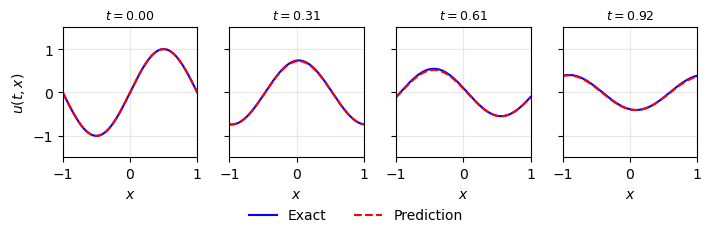

In [15]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        x_test,
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        x_test,
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={t_test[idx]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1.5,1.5])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)

fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)

# fig.savefig("Linear_Transport_version_1.png", dpi=300, bbox_inches='tight')
